# *Лабораторная работа №2*

## Построение бинарного классификатора на основе нейронных сетей (Теоретическая часть)

Мы продолжаем работу над датасетом с данными о проданных подержанных автомобилях в Германии в 2016 году (см. https://colab.research.google.com/drive/1fl7f7-8WA5GIjZ6qghfiD_2sEaCc1DQH?usp=sharing). В рамках текущей лабораторной необходимо построить модель бинарного классификатора на основе нейронных сетей, который бы позволил определить была ли машина в ремонте или нет.


Подключим все необходимые для дальнейшей работы библиотеки.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from keras import models
from keras import layers

import warnings
warnings.filterwarnings("ignore")

Загрузим базу данных, которая была получена нами в ходе предыдущей работы, т.е. в ней уже проведена определенная работа по очистке данных (подробнее см. лаб1).

In [2]:
%%capture
!wget -O autos_mod.csv https://www.dropbox.com/scl/fi/t0wr6jge6wwzoff2upd9q/autos_mod_2025.csv?rlkey=sak848n8x96h5gz1383rzck6m&st=klg3z8my&dl=0

Записываем ее в датафрейм и проверим столбцы на наличие пустых значений.

In [1]:
df = pd.read_csv('autos_mod.csv')
df.isnull().any()

NameError: name 'pd' is not defined

Удалим столбец, который возник в процессе переписывания набора данных, так как никакой полезной информации он не несет.

In [4]:
del df["Unnamed: 0"]

Проверим, что у нас не осталось записей с пустыми значениями.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250919 entries, 0 to 250918
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   price               250919 non-null  int64
 1   vehicleType         250919 non-null  int64
 2   yearOfRegistration  250919 non-null  int64
 3   gearbox             250919 non-null  int64
 4   powerPS             250919 non-null  int64
 5   model               250919 non-null  int64
 6   kilometer           250919 non-null  int64
 7   fuelType            250919 non-null  int64
 8   brand               250919 non-null  int64
 9   notRepairedDamage   250919 non-null  int64
dtypes: int64(10)
memory usage: 19.1 MB


Разобьем весь наш набора данных на тренировочный и тестовый наборы данных.

In [7]:
values = df['notRepairedDamage']
points = df.drop(['notRepairedDamage'], axis=1)
train_points, test_points, train_values, test_values = train_test_split(points, values, test_size = 0.2)

Так как библиотека keras не позволяет фиксировать зерно рандома в процессе обучения модели, измерение следует проводить несколько раз и усреднять полученные значения.

In [8]:
model = models.Sequential()

model.add(layers.Dense(12, activation = "relu", input_shape = (9,)))

model.add(layers.Dense(15, activation = "relu"))

model.add(layers.Dense(1, activation = "sigmoid"))

model.compile(
 optimizer = "adam",
 loss = "binary_crossentropy",
 metrics = ["accuracy"]
)
results = model.fit(
 train_points, train_values,
 epochs= 5,
 batch_size = 500,
 validation_data = (test_points, test_values)
)
print("Test-Accuracy:", results.history["val_accuracy"][-1])

Epoch 1/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8519 - loss: 650.5780 - val_accuracy: 0.8961 - val_loss: 12.6193
Epoch 2/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8356 - loss: 16.9519 - val_accuracy: 0.8236 - val_loss: 52.4025
Epoch 3/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8410 - loss: 11.5369 - val_accuracy: 0.8821 - val_loss: 168.2913
Epoch 4/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8366 - loss: 81.1073 - val_accuracy: 0.8961 - val_loss: 5.8734
Epoch 5/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8372 - loss: 21.3959 - val_accuracy: 0.8958 - val_loss: 39.2768
Test-Accuracy: 0.895783543586731


Рассмотрим ключевые гиперпараметры создания и обучения нейронной сети:

1. **Количество слоев и количество нейронов на них.** Первый слой является входным и количество нейронов на нем обычно совпадает с размерностью подаваемого на вход вектора значений. На выходном слое количество нейронов должно определяться решаемой задачей: для задачи бинарной классификации и регрессии должен быть один нейрон, для мультиклассовой - по количеству предсказываемых классов. Промежуточные(скрытые) слои отвечают за сложность поведения модели, чем больше слоев, тем более сложное поведение может быть смоделировано нейронной сетью, если это позволяют исходные данные. Количество нейронов на скрытом слое отвечает за количество комбинаций сигналов нейронов предыдущего слоя, которые будут рассматриваться.

2. **Функции активации нейронов на слоях.** К функциям активации нейронов относятся: relu, sigmoid и [другие](https://ru-keras.com/activation-function). ReLu является наиболее примитивной функцией активации, обладающей наиболее простой, с точки зрения вычисления, производной, что обеспечивает высокую скорость обучения и работы сети. Но для нее наиболее характерно затухание градиента, когда обучение останавливается, несмотря на высокое значение функции потерь. Гиперболический тангенс и сигмоида в меньшей степени подвержены эффекту затухания градиента, но и вычисления с их участием занимают более длительное время.

3. **Оптимизатор.** Про оптимизаторы подробнее можно почитать, например, [здесь](https://ru-keras.com/optimizer). Оптимизатор отвечает за то, каким образом нейронная сеть будет корректировать веса в процессе обучения. Наиболее общеупотребимым в различных обучающих материалах является adam.

4. **Количество эпох обучения.** Любой процесс обучения рано или поздно упрется в "потолок" по качеству. С помощью количества эпох можно контролировать, насколько близко к этому потолку приблизится модель. Но следует помнить про эффект переобучения: слишком большое количество прогонов тренировочных данных снижает способность нейронной сети к обощению.

5. **Размер пакета обучения.** В идеальном мире нейронная сеть осуществляет корректировку своих весов после каждого обработанного примера, но это существенно увеличит время обучения. При оборачивании всего тренировочного датасета в единый пакет время обучения будет минимальным, но значительно снизится способность нейронной сети к обобщению.  

Приведенную выше модель нейронной сети будем считать отправной точкой.

Данная модель демонстрирует крайнюю неустойчивость, так как при каждом запуске значение точности на разных эпохах сильно разнится. Проверим, как изменится поведение модели в ходе обучения, если мы поменяем функцию активации на сигмоиду.

In [9]:
model = models.Sequential()

model.add(layers.Dense(12, activation = "sigmoid", input_shape = (9,)))

model.add(layers.Dense(15, activation = "sigmoid"))

model.add(layers.Dense(1, activation = "sigmoid"))

model.compile(
 optimizer = "adam",
 loss = "binary_crossentropy",
 metrics = ["accuracy"]
)
results = model.fit(
 train_points, train_values,
 epochs= 5,
 batch_size = 500,
 validation_data = (test_points, test_values)
)
print("Test-Accuracy:", results.history["val_accuracy"][-1])

Epoch 1/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7226 - loss: 0.5231 - val_accuracy: 0.8961 - val_loss: 0.3357
Epoch 2/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8985 - loss: 0.3300 - val_accuracy: 0.8961 - val_loss: 0.3348
Epoch 3/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8978 - loss: 0.3306 - val_accuracy: 0.8961 - val_loss: 0.3336
Epoch 4/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8988 - loss: 0.3274 - val_accuracy: 0.8961 - val_loss: 0.3309
Epoch 5/5
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8979 - loss: 0.3255 - val_accuracy: 0.8961 - val_loss: 0.3334
Test-Accuracy: 0.8960624933242798


Значения функции потерь и точности стабилизировались, что говорит о более устойчивой сходимости процесса обучения. В случае с сигмоидой обучение можно останавливать после второй эпохи обучения, так как на валидационных данных модель вышла на асимптоту. Рассмотрим, будет ли достигнута подобная стабильность при использовании relu с большим количеством эпох.

In [10]:
model = models.Sequential()

model.add(layers.Dense(12, activation = "relu", input_shape = (9,)))

model.add(layers.Dense(15, activation = "relu"))

model.add(layers.Dense(1, activation = "sigmoid"))

model.compile(
 optimizer = "adam",
 loss = "binary_crossentropy",
 metrics = ["accuracy"]
)
results = model.fit(
 train_points, train_values,
 epochs= 10,
 batch_size = 500,
 validation_data = (test_points, test_values)
)
print("Test-Accuracy:", results.history["val_accuracy"][-1])

Epoch 1/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8535 - loss: 432.6982 - val_accuracy: 0.8860 - val_loss: 9.2571
Epoch 2/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8217 - loss: 79.8727 - val_accuracy: 0.8951 - val_loss: 18.6113
Epoch 3/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8217 - loss: 214.0284 - val_accuracy: 0.8961 - val_loss: 24.3010
Epoch 4/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8236 - loss: 44.6331 - val_accuracy: 0.7507 - val_loss: 4.2117
Epoch 5/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8281 - loss: 23.4833 - val_accuracy: 0.8075 - val_loss: 8.4454
Epoch 6/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8464 - loss: 15.0214 - val_accuracy: 0.8938 - val_loss: 51.6512
Epoch 7/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8451 - loss: 22.1968 - val_accuracy: 0.8944 - val_loss: 23.4053
Epoch 8/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8258 - loss: 29.3234 - va

Попробуем ввести дополнительный скрытый слой в сеть, чтобы упростить задачу классификации выходному слою нейронов.

In [11]:
model = models.Sequential()

model.add(layers.Dense(10, activation = "relu", input_shape = (9,)))

model.add(layers.Dense(15, activation = "relu"))

model.add(layers.Dense(8, activation = "relu"))

model.add(layers.Dense(1, activation = "sigmoid"))

model.compile(
 optimizer = "adam",
 loss = "binary_crossentropy",
 metrics = ["accuracy"]
)
results = model.fit(
 train_points, train_values,
 epochs= 10,
 batch_size = 500,
 validation_data = (test_points, test_values)
)
print("Test-Accuracy:", results.history["val_accuracy"][-1])

Epoch 1/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7597 - loss: 526.2490 - val_accuracy: 0.8771 - val_loss: 11.7884
Epoch 2/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8419 - loss: 17.3767 - val_accuracy: 0.8606 - val_loss: 60.1273
Epoch 3/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8192 - loss: 41.3193 - val_accuracy: 0.8914 - val_loss: 23.6211
Epoch 4/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8250 - loss: 38.3515 - val_accuracy: 0.8939 - val_loss: 27.3421
Epoch 5/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8311 - loss: 17.4594 - val_accuracy: 0.8533 - val_loss: 59.1939
Epoch 6/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8273 - loss: 37.8305 - val_accuracy: 0.7257 - val_loss: 4.6810
Epoch 7/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8276 - loss: 13.9655 - val_accuracy: 0.8796 - val_loss: 54.8634
Epoch 8/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8380 - loss: 22.3539 - v

Благодаря уменьшению количества нейронов на предпоследнем слое, нейронная сеть смогла с большей точностью определять ключевые компоненты и учитывать их при вынесении вердикта о принадлежности объекта тому или иному классу.

Кроме работы непосредственно с моделями и их составляющими, можно попробовать преобразовать данные для их лучшей интерпретируемости системой. В данном случае, поле года выпуска автомобиля имеет плохую форму распределения.

<Axes: >

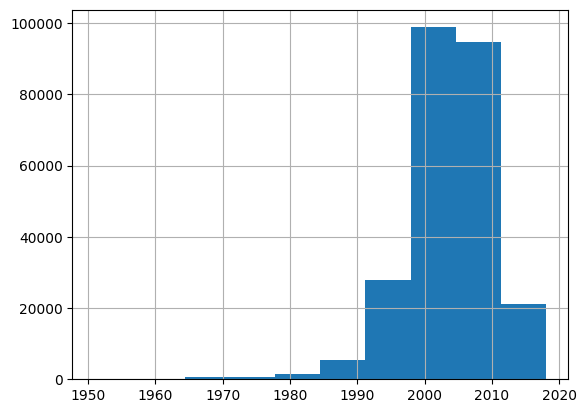

In [12]:
df['yearOfRegistration'].hist()

Введем вместо него поле с возрастом.

In [13]:
df['age'] = 2020 - df['yearOfRegistration']
del df['yearOfRegistration']
df.head()

,price,vehicleType,gearbox,powerPS,model,kilometer,fuelType,brand,notRepairedDamage,age
0,1500,0,0,75,0,150000,0,0,0,19
1,3600,0,0,69,1,90000,1,1,0,12
2,650,1,0,102,2,150000,0,2,1,25
3,2200,2,0,109,3,150000,0,3,0,16
4,0,1,0,50,4,40000,0,0,0,40


In [14]:
values = df['notRepairedDamage']
points = df.drop(['notRepairedDamage'], axis=1)
train_points, test_points, train_values, test_values = train_test_split(points, values, test_size = 0.2)

In [15]:
model = models.Sequential()

model.add(layers.Dense(12, activation = "relu", input_shape = (9,)))

model.add(layers.Dense(15, activation = "relu"))

model.add(layers.Dense(8, activation = "relu"))

model.add(layers.Dense(1, activation = "sigmoid"))

model.compile(
 optimizer = "adam",
 loss = "binary_crossentropy",
 metrics = ["accuracy"]
)
results = model.fit(
 train_points, train_values,
 epochs= 10,
 batch_size = 500,
 validation_data = (test_points, test_values)
)
print("Test-Accuracy:", results.history["val_accuracy"][-1])

Epoch 1/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8334 - loss: 4.0819 - val_accuracy: 0.8995 - val_loss: 11.5645
Epoch 2/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8983 - loss: 0.5372 - val_accuracy: 0.8995 - val_loss: 11.4898
Epoch 3/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8974 - loss: 0.4580 - val_accuracy: 0.8995 - val_loss: 11.4396
Epoch 4/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8985 - loss: 0.4061 - val_accuracy: 0.8995 - val_loss: 11.4082
Epoch 5/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8976 - loss: 0.3751 - val_accuracy: 0.8995 - val_loss: 11.3892
Epoch 6/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8978 - loss: 0.3551 - val_accuracy: 0.8995 - val_loss: 11.3785
Epoch 7/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8977 - loss: 0.3435 - val_accuracy: 0.8995 - val_loss: 11.3729
Epoch 8/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8972 - loss: 0.3377 - val_accur

Для обеих моделей мы получили увеличение точности. Попробуем пойти еще немного дальше, объединив два поля в одно. Такой подход называют уменьшением размерности, так как он позволяет работать с входным вектором меньшего размера.

In [16]:
df['intence'] = df['kilometer']/df['age']
del df['kilometer']
del df['age']

In [17]:
values = df['notRepairedDamage']
points = df.drop(['notRepairedDamage'], axis=1)
train_points, test_points, train_values, test_values = train_test_split(points, values, test_size = 0.2)

In [18]:
model = models.Sequential()

model.add(layers.Dense(12, activation = "relu", input_shape = (8,)))

model.add(layers.Dense(15, activation = "relu"))

model.add(layers.Dense(8, activation = "relu"))

model.add(layers.Dense(1, activation = "sigmoid"))

model.compile(
 optimizer = "adam",
 loss = "binary_crossentropy",
 metrics = ["accuracy"]
)
results = model.fit(
 train_points, train_values,
 epochs= 10,
 batch_size = 500,
 validation_data = (test_points, test_values)
)
print("Test-Accuracy:", results.history["val_accuracy"][-1])

Epoch 1/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8490 - loss: 23.0251 - val_accuracy: 0.8703 - val_loss: 1.7075
Epoch 2/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8615 - loss: 7.5943 - val_accuracy: 0.7963 - val_loss: 2.0657
Epoch 3/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8213 - loss: 22.6152 - val_accuracy: 0.8624 - val_loss: 2.0021
Epoch 4/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8461 - loss: 11.8801 - val_accuracy: 0.8853 - val_loss: 6.7652
Epoch 5/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8525 - loss: 5.7874 - val_accuracy: 0.8069 - val_loss: 235.1974
Epoch 6/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8614 - loss: 22.6774 - val_accuracy: 0.8887 - val_loss: 1.2259
Epoch 7/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8731 - loss: 4.9255 - val_accuracy: 0.8682 - val_loss: 94.3773
Epoch 8/10
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8786 - loss: 5.8224 - val_accur

Уменьшение размерности нашего входного вектора не привело к улучшению общей картины. Не всегда одни и те же шаги приводят к одному и тому же результату. Из-за специфики датасета действенность метода может очень сильно варьироваться.

## Построение бинарного классификатора (Практическая часть)

Вашим заданием в данной лабораторной будет построение бинарного классификатора на основе нейронных сетей для предсказания возможного ухода клиента из банка и оценка влияния параметров НС на получаемый результат. Задание основано на следующем датасете https://www.kaggle.com/datasets/willianoliveiragibin/bank-churn-prediction?resource=download.

Ниже приведены инструкции для загрузки тренировочной и валидационной части датасета. Для них, в случае необходимости, следует провести предварительную обработку данных.

In [ ]:
%%capture
!wget -O bank_train.csv https://www.dropbox.com/scl/fi/rz8xmydm1h3bpgjjm30jd/bank_train.csv?rlkey=rylj5xs1icbfokyabtnqo5gdv&dl=0
!wget -O bank_valid.csv https://www.dropbox.com/scl/fi/05p2v6pw76tjf7c21rcyb/bank_valid.csv?rlkey=ifbgda9mj7ybbgl2txnzjq9g1&dl=0

В качестве отчета к работе необходимо предоставить диаграммы отражающие связь между гиперпараметрами нейронных сетей (количество слоев, количество нейронов на слоях, функция активации, используемый оптимизатор, количество эпох обучения, размер пакета) и получаемой точностью модели, а так же временем обучения.